In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports OK")

✅ All imports OK


In [2]:
# Cell 2 — Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target * 100000  # Convert to CHF (realistic Swiss prices)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns)}")
print(f"\nPrice range: CHF {df['Price'].min():,.0f} — CHF {df['Price'].max():,.0f}")
print(f"Average price: CHF {df['Price'].mean():,.0f}")
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

Price range: CHF 14,999 — CHF 500,001
Average price: CHF 206,856


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


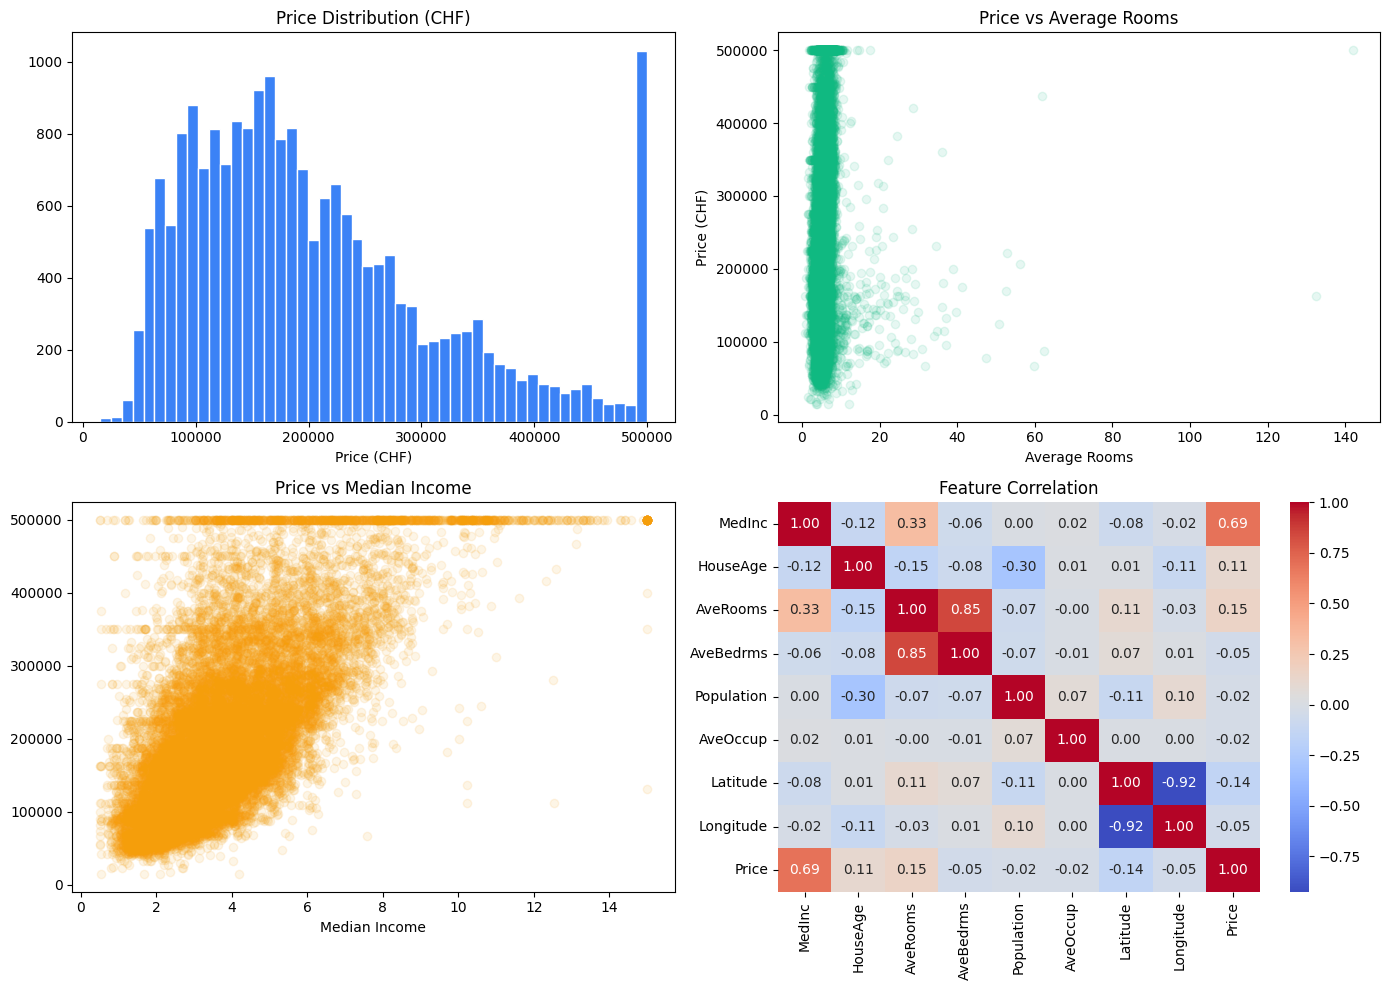

✅ EDA plots saved


In [9]:
# Cell 3 — EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(df['Price'], bins=50, color='#3B82F6', edgecolor='white')
axes[0, 0].set_title('Price Distribution (CHF)')
axes[0, 0].set_xlabel('Price (CHF)')

# Price vs rooms
axes[0, 1].scatter(df['AveRooms'], df['Price'], alpha=0.1, color='#10B981')
axes[0, 1].set_title('Price vs Average Rooms')
axes[0, 1].set_xlabel('Average Rooms')
axes[0, 1].set_ylabel('Price (CHF)')

# Price vs income
axes[1, 0].scatter(df['MedInc'], df['Price'], alpha=0.1, color='#F59E0B')
axes[1, 0].set_title('Price vs Median Income')
axes[1, 0].set_xlabel('Median Income')

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved")

In [6]:
# Cell 4 — Train & compare models
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'model': model}
    print(f"{name}: R²={r2:.4f} | RMSE=CHF {rmse:,.0f} | MAE=CHF {mae:,.0f}")

print("\n✅ Training complete")

Linear Regression: R²=0.5758 | RMSE=CHF 74,558 | MAE=CHF 53,320
Random Forest: R²=0.8038 | RMSE=CHF 50,710 | MAE=CHF 32,812
XGBoost: R²=0.8301 | RMSE=CHF 47,179 | MAE=CHF 30,957

✅ Training complete


In [11]:
# Cell 5 — Save best model
import os

MODEL_DIR = r"C:\Users\Gerard\Desktop\Predictor-Precios-Suiza\backend\app\model"
os.makedirs(MODEL_DIR, exist_ok=True)

best_model = results['XGBoost']['model']
joblib.dump(best_model, os.path.join(MODEL_DIR, 'house_price_model.pkl'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))

import json
feature_stats = {
    'features': list(X.columns),
    'feature_mins': X.min().to_dict(),
    'feature_maxs': X.max().to_dict(),
    'feature_means': X.mean().to_dict(),
    'price_min': float(y.min()),
    'price_max': float(y.max()),
    'price_mean': float(y.mean()),
    'model_r2': results['XGBoost']['R2'],
    'model_rmse': results['XGBoost']['RMSE'],
    'model_mae': results['XGBoost']['MAE'],
}
with open(os.path.join(MODEL_DIR, 'model_stats.json'), 'w') as f:
    json.dump(feature_stats, f, indent=2)

print("✅ Model saved!")
print(f"Files: {os.listdir(MODEL_DIR)}")

✅ Model saved!
Files: ['house_price_model.pkl', 'model_stats.json', 'scaler.pkl']


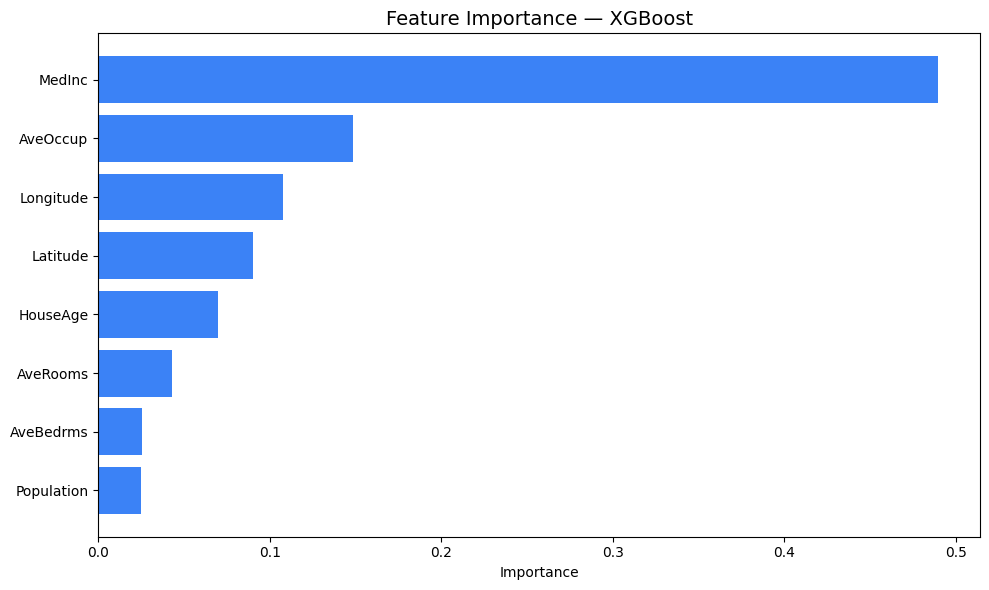


📊 Feature importance:
   Population: 0.0247
   AveBedrms: 0.0257
   AveRooms: 0.0431
   HouseAge: 0.0701
   Latitude: 0.0903
   Longitude: 0.1080
   AveOccup: 0.1486
   MedInc: 0.4896


In [8]:
# Cell 6 — Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#3B82F6')
plt.title('Feature Importance — XGBoost', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Feature importance:")
for _, row in feature_importance.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")